<link href="https://fonts.googleapis.com/css2?family=Great+Vibes&display=swap" rel="stylesheet">

<h2 style="
text-align:center;
color:white;
font-family:'Great Vibes', cursive;
font-size:32px;
letter-spacing:2px;">
🎬 Movie Rating Prediction 🎬
</h2>

<p style="
text-align:center;
color:white;
font-size:14px;
font-family:'Great Vibes', cursive;">
Machine Learning Project
</p>

#### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from IPython.display import display

#### Load Dataset


In [2]:
try:
    data = pd.read_csv("movies.csv")
except:
    data = pd.read_csv("movies.csv", encoding='latin1')   

In [3]:
print("Dataset Shape:", data.shape)
print("Columns:", data.columns)

Dataset Shape: (15509, 10)
Columns: Index(['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director',
       'Actor 1', 'Actor 2', 'Actor 3'],
      dtype='object')


In [4]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1200)
display(data.head(10))

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali
5,...Aur Pyaar Ho Gaya,(1997),147 min,"Comedy, Drama, Musical",4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor
6,...Yahaan,(2005),142 min,"Drama, Romance, War",7.4,"1,086",Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma
7,.in for Motion,(2008),59 min,Documentary,NaN,NaN,Anirban Datta,NaN,NaN,NaN
8,?: A Question Mark,(2012),82 min,"Horror, Mystery, Thriller",5.6,326,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia
9,@Andheri,(2014),116 min,"Action, Crime, Thriller",4.0,11,Biju Bhaskar Nair,Augustine,Fathima Babu,Byon


#### Data Cleaning


In [5]:
# Removing rows where movie name is missing
data = data[data['Name'].notna()]

# Removing unwanted blank spaces
data = data.replace(' ', np.nan)

# Strip spaces from text columns
for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = data[col].str.strip()

# Cleaning Year column (removing brackets)
if 'Year' in data.columns:
    data['Year'] = data['Year'].str.replace('(', '')
    data['Year'] = data['Year'].str.replace(')', '')
    data['Year'] = pd.to_numeric(data['Year'], errors='coerce')

# Cleaning Duration column (removing 'min')
if 'Duration' in data.columns:
    data['Duration'] = data['Duration'].str.replace('min', '')
    data['Duration'] = pd.to_numeric(data['Duration'], errors='coerce')

# Cleaning Votes column (removing commas)
if 'Votes' in data.columns:
    data['Votes'] = data['Votes'].str.replace(',', '')
    data['Votes'] = pd.to_numeric(data['Votes'], errors='coerce')

# Filling missing values using forward fill
data = data.fillna(method='ffill')


#### Encode Categorical Columns


In [6]:
le = LabelEncoder()

for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = le.fit_transform(data[col])

##### Keep Numeric Data Only


In [7]:
numeric_data = data.select_dtypes(include=[np.number])

# Fill remaining NaN with median
numeric_data = numeric_data.fillna(numeric_data.median())

### Visualization

###### Rating Distribution

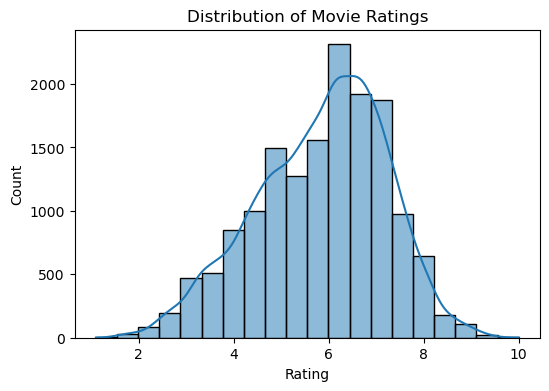

In [8]:
plt.figure(figsize=(6,4))
sns.histplot(numeric_data['Rating'], bins=20, kde=True)
plt.title("Distribution of Movie Ratings")
plt.show()


###### Boxplot


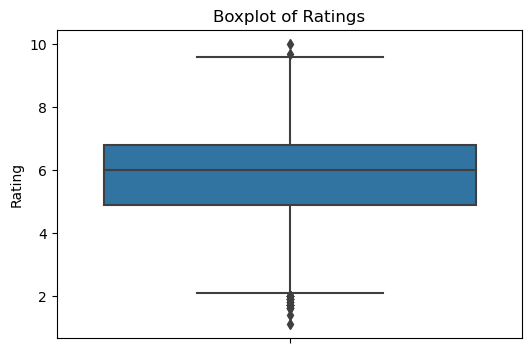

In [9]:
plt.figure(figsize=(6,4))
sns.boxplot(y=numeric_data['Rating'])
plt.title("Boxplot of Ratings")
plt.show()

###### Correlation Heatmap


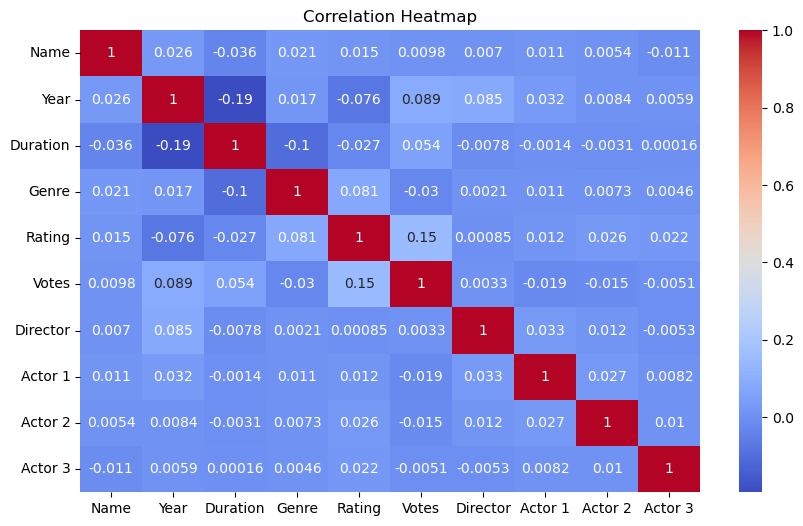

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(numeric_data.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


###### Features and Target


In [11]:
X = numeric_data.drop('Rating', axis=1)
y = numeric_data['Rating']

#### Train Test Split


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

 #### Model Training

In [13]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

#### Prediction


In [14]:
y_pred = model.predict(X_test)

##### Evaluation

In [15]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 1.8560434653043345
R2 Score: 0.03936827249792274


##### Actual vs Predicted

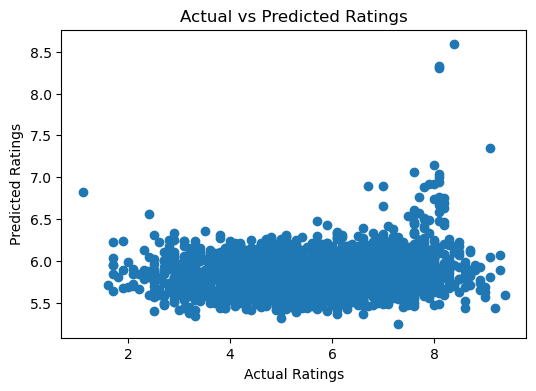

In [16]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs Predicted Ratings")
plt.show()

##### Residual Plot

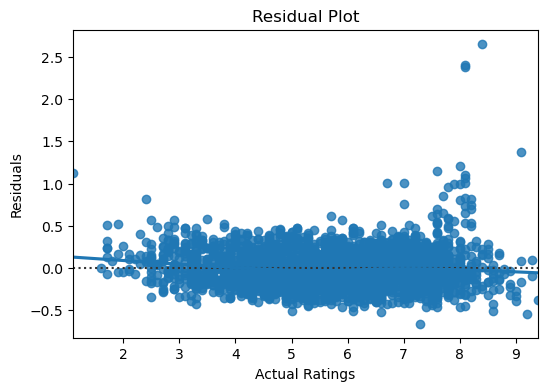

In [17]:
plt.figure(figsize=(6,4))
sns.residplot(x=y_test, y=y_pred, lowess=True)
plt.xlabel("Actual Ratings")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()